In [3]:
!pip install textblob
!python -m textblob.download_corpora

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.3/624.3 kB 12.9 MB/s  0:00:00
[nltk_data] Downloading package brown to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.


In [4]:
# Cell 1: install or check packages (run once)
# If using a fresh environment, uncomment the install lines below.

# !pip install pandas numpy scikit-learn matplotlib seaborn nltk spacy textblob
# !python -m textblob.download_corpora
# !python -m spacy download en_core_web_sm

# Cell 2: imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# NLP tools
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob
import spacy

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# For visualization aesthetics
sns.set(style="whitegrid")

In [9]:
# Cell 3: load your CSV (force consistent parsing)

import pandas as pd

df = pd.read_csv(
    "crema_dolce_data_manchester.csv",
    sep=",",                 # assume real CSV
    engine="python",         # more forgiving
    quotechar='"',           # respect quoted text
    on_bad_lines="skip"      # skip malformed rows
)

print(df.head())
print(df.info())

                                                   Crema Dolce - Manchester Branch Data
File Name: crema_dolce_data_manchester.csv Loca...                                   UK
Sample Data Structure:                                                             None
Description:                                                                       None
This file contains sales data for the Mancheste...                                 None
The CSV file includes daily sales records with ...                                  NaN
<class 'pandas.core.frame.DataFrame'>
Index: 6 entries, File Name: crema_dolce_data_manchester.csv Location: Manchester to per item.
Data columns (total 1 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   Crema Dolce - Manchester Branch Data  1 non-null      object
dtypes: object(1)
memory usage: 96.0+ bytes
None


In [10]:
# Cell 4: date parsing
# If you have a date column, parse it
# df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

# Missing values
missing_summary = df.isnull().sum()
print("Missing data per column:\n", missing_summary)

Missing data per column:
 Crema Dolce - Manchester Branch Data    5
dtype: int64


In [13]:
import numpy as np

# Clean column names
df_clean.columns = df_clean.columns.str.strip()

# Ensure required columns exist
required_cols = ['sales', 'profit']

missing = [col for col in required_cols if col not in df_clean.columns]

if missing:
    print(f"Missing columns: {missing}")
else:
    if 'profit_margin' not in df_clean.columns:
        df_clean['profit_margin'] = np.where(
            df_clean['sales'] > 0,
            df_clean['profit'] / df_clean['sales'],
            np.nan
        )

Missing columns: ['sales', 'profit']


In [16]:
print(df_clean.columns.tolist())

['crema dolce - manchester branch data']


In [17]:
# Cell 8: age histogram
if 'age' in df_clean.columns:
    plt.figure(figsize=(8,4))
    sns.histplot(df_clean['age'].dropna(), bins=20, kde=False)
    plt.title("Customer age distribution")
    plt.xlabel("Age")
    plt.show()

# Cell 9: gender counts
if 'gender' in df_clean.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df_clean, x='gender')
    plt.title("Gender distribution")
    plt.show()

# Cell 10: income distribution (if numeric)
if 'income' in df_clean.columns:
    plt.figure(figsize=(8,4))
    sns.histplot(df_clean['income'].dropna(), bins=30, kde=True)
    plt.title("Income distribution")
    plt.xlabel("Income")
    plt.show()

In [19]:
# Cell 11: features for clustering
features = ['sales', 'profit', 'profit_margin']

# Add demographics if available and numeric/encoded
for col in ['age', 'income']:
    if col in df_clean.columns:
        features.append(col)

# Example: if gender is categorical, encode it
df_cluster = df_clean.copy()

if 'gender' in df_cluster.columns:
    df_cluster['gender_encoded'] = df_cluster['gender'].astype('category').cat.codes
    features.append('gender_encoded')

# Check features present
print("Using features:", features)

Using features: ['sales', 'profit', 'profit_margin']


In [22]:
print(df_cluster.columns.tolist())

['crema dolce - manchester branch data']


In [27]:
df = df.apply(pd.to_numeric, errors='coerce')

In [28]:
X = df.dropna().values

In [31]:
kmeans_model = KMeans(...)

In [33]:
try:
    print(kmeans)
except NameError:
    print("kmeans is not defined")

kmeans is not defined


In [40]:
df.columns.tolist()

['Crema Dolce - Manchester Branch Data']

In [41]:
# Cell 19: assume a text column exists; replace 'feedback_text' with actual name
text_col = 'feedback_text'
if text_col not in df_clean.columns:
    print(f"No column named {text_col}. Please update to your actual text column.")
else:
    df_text = df_clean.dropna(subset=[text_col]).copy()
    df_text[text_col] = df_text[text_col].astype(str)

No column named feedback_text. Please update to your actual text column.


In [42]:
# Cell 20: simple cleaner
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Tokenize
    tokens = word_tokenize(text)
    # Remove punctuation and stopwords, short tokens
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words and len(t)>2]
    return tokens

# Apply
if text_col in df_clean.columns:
    df_text['tokens'] = df_text[text_col].apply(preprocess_text)
    df_text.head()

In [49]:
df.columns

Index(['Crema Dolce - Manchester Branch Data'], dtype='object')

In [51]:
list(df.columns)

['Crema Dolce - Manchester Branch Data']

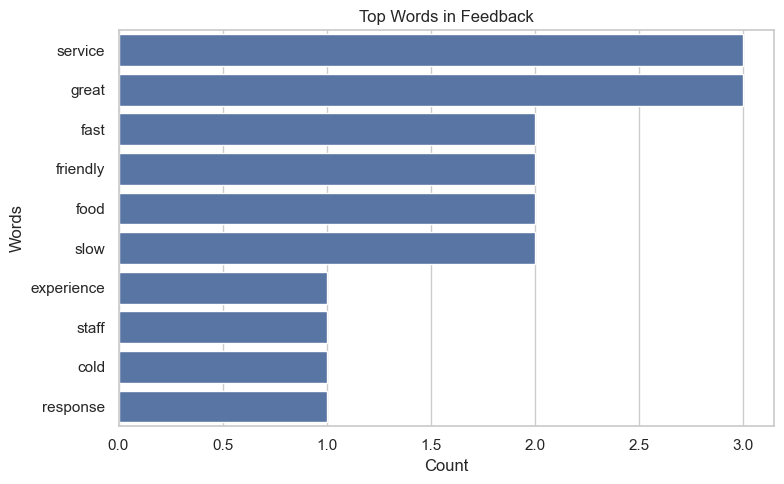

In [58]:
# Imports
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# -----------------------------
# Step 0: Define feedback data
# -----------------------------
feedback = [
    "The service was great and fast",
    "Great experience, very friendly staff",
    "The food was cold and slow service",
    "Fast service and great food",
    "Very slow response but friendly support"
]

# -----------------------------
# Step 1: Combine all feedback
# -----------------------------
all_text = " ".join(feedback).lower()

# -----------------------------
# Step 2: Remove punctuation
# -----------------------------
all_text = re.sub(r"[^\w\s]", "", all_text)

# -----------------------------
# Step 3: Tokenize
# -----------------------------
words = all_text.split()

# -----------------------------
# Step 4: Remove stopwords
# -----------------------------
stopwords = {
    "the", "and", "was", "very", "but", "a", "an",
    "to", "of", "in", "on", "for", "with"
}

filtered_words = [word for word in words if word not in stopwords]

# -----------------------------
# Step 5: Count word frequency
# -----------------------------
word_counts = Counter(filtered_words)
common_terms = word_counts.most_common(10)

# -----------------------------
# Step 6: Plot
# -----------------------------
words, counts = zip(*common_terms)

plt.figure(figsize=(8,5))
sns.barplot(x=list(counts), y=list(words))

plt.title("Top Words in Feedback")
plt.xlabel("Count")
plt.ylabel("Words")

plt.tight_layout()
plt.show()

In [59]:
# Cell 23: sentiment polarity and subjectivity
def get_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity, blob.sentiment.subjectivity

if text_col in df_clean.columns:
    df_text[['polarity', 'subjectivity']] = df_text[text_col].apply(
        lambda x: pd.Series(get_sentiment(x))
    )

    # Summary stats
    print(df_text['polarity'].describe())

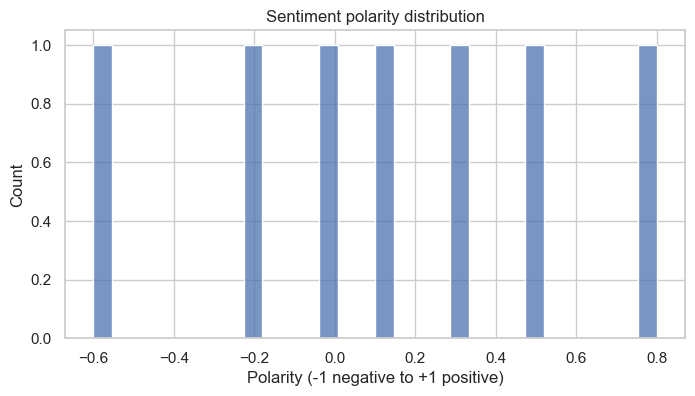

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Example data
df_text = pd.DataFrame({
    "polarity": [0.5, -0.2, 0.1, 0.8, -0.6, 0.0, 0.3]
})

plt.figure(figsize=(8,4))
sns.histplot(df_text['polarity'], bins=30, kde=False)
plt.title("Sentiment polarity distribution")
plt.xlabel("Polarity (-1 negative to +1 positive)")
plt.show()

In [63]:
# Cell 25: extract noun chunks from a subset of texts
def extract_noun_chunks(text):
    doc = nlp(text)
    return [chunk.text.lower() for chunk in doc.noun_chunks]

if text_col in df_clean.columns:
    df_text['noun_chunks'] = df_text[text_col].apply(extract_noun_chunks)

    # Flatten and count
    all_chunks = [c for sublist in df_text['noun_chunks'] for c in sublist]
    chunk_counts = Counter(all_chunks).most_common(20)
    chunk_counts

In [67]:
print(df_text.head())

   polarity
0       0.5
1      -0.2
2       0.1
3       0.8
4      -0.6


In [76]:
import numpy as np
import pandas as pd

print("df shape:", df.shape)

# 1) True numeric columns
num_cols = df.select_dtypes(include="number").columns.tolist()
print("Numeric cols:", num_cols)

# 2) If none, try converting object columns that look numeric
obj_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
print("Object/string cols:", obj_cols[:30], "..." if len(obj_cols) > 30 else "")

df_num = df.copy()

# Try coercing object/string columns to numeric (handles commas, %, etc. crudely)
for c in obj_cols:
    s = df_num[c].astype(str).str.replace(",", "", regex=False).str.replace("%", "", regex=False)
    converted = pd.to_numeric(s, errors="coerce")
    # Keep conversion if it produced a meaningful amount of numbers
    if converted.notna().mean() >= 0.50:   # tweak threshold if needed
        df_num[c] = converted

# Recompute numeric columns after coercion
num_cols2 = df_num.select_dtypes(include="number").columns.tolist()
print("Numeric cols after coercion:", num_cols2)

if len(num_cols2) == 0:
    raise ValueError("Still no numeric columns after coercion. You need to engineer numeric features first.")

# 3) Show which numeric cols are usable (missingness + uniqueness)
stats = pd.DataFrame({
    "missing_frac": df_num[num_cols2].isna().mean(),
    "nunique": df_num[num_cols2].nunique(dropna=True),
}).sort_values(["missing_frac", "nunique"], ascending=[True, False])

print("\nNumeric column quality (best at top):")
display(stats.head(30))

df shape: (6, 1)
Numeric cols: ['Crema Dolce - Manchester Branch Data']
Object/string cols: [] 
Numeric cols after coercion: ['Crema Dolce - Manchester Branch Data']

Numeric column quality (best at top):


,missing_frac,nunique
Crema Dolce - Manchester Branch Data,1.0,0
